In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

dirname = '../data/Health_Dataset/'
filename = 'health_dataset.csv'
df = pd.read_csv(dirname + filename)

In [87]:
# Display the first few rows of the dataset
print('First few rows of the dataset:')
df.head()

First few rows of the dataset:


,ADM_RNO1,Province,Health_region_ grouped,Gender,Marital_status,Household,Age,Worked_job_business,Edu_level,Gen_health_state,...,Physical_vigorous_act_time,Work_hours,working_status,Aboriginal_identity,Birth_country,Immigrant,Insurance_cover,Food_security,Income_source,Total_income
0,1000,47,47906,2,1,2,3,1,3,3,...,10,38,1,2,1,2,1,0,1,5
1,100005,47,47906,1,1,2,5,6,2,3,...,0,96,6,2,1,2,1,0,2,4
2,100012,59,59914,2,2,1,5,6,1,2,...,9996,96,6,2,1,2,6,6,2,2
3,100015,13,13904,1,2,1,5,6,1,3,...,9996,96,6,2,1,2,6,0,2,3
4,100018,46,46903,1,2,1,4,2,3,5,...,9996,96,6,2,1,2,2,0,2,1


In [88]:
df.describe()

,ADM_RNO1,Province,Health_region_ grouped,Gender,Marital_status,Household,Age,Worked_job_business,Edu_level,Gen_health_state,...,Physical_vigorous_act_time,Work_hours,working_status,Aboriginal_identity,Birth_country,Immigrant,Insurance_cover,Food_security,Income_source,Total_income
count,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.00000,...,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000,108252.000000
mean,501094.332844,34.405683,35330.737908,1.544729,1.748365,1.720763,3.825324,3.659489,3.001912,2.44377,...,8118.493497,75.402496,4.293694,2.171618,1.325407,1.979659,5.151036,1.008101,2.338322,3.897794
std,288978.471309,15.260020,15267.165483,0.497998,1.258188,0.686516,1.293388,2.460041,1.565288,1.06486,...,3897.281466,28.343824,2.385646,1.193865,1.170483,1.071780,1.849489,2.212104,2.488297,1.522599
min,21.000000,10.000000,10911.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
25%,250614.500000,24.000000,24906.000000,1.000000,1.000000,1.000000,3.000000,1.000000,3.000000,2.00000,...,9996.000000,42.000000,1.000000,2.000000,1.000000,2.000000,6.000000,0.000000,1.000000,3.000000
50%,502202.500000,35.000000,35949.000000,2.000000,1.000000,2.000000,4.000000,6.000000,3.000000,2.00000,...,9996.000000,96.000000,6.000000,2.000000,1.000000,2.000000,6.000000,0.000000,2.000000,4.000000
75%,751549.250000,47.000000,47906.000000,2.000000,2.000000,2.000000,5.000000,6.000000,3.000000,3.00000,...,9996.000000,96.000000,6.000000,2.000000,1.000000,2.000000,6.000000,0.000000,2.000000,5.000000
max,999998.000000,60.000000,60901.000000,2.000000,9.000000,9.000000,5.000000,9.000000,9.000000,8.00000,...,9999.000000,99.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108252 entries, 0 to 108251
Data columns (total 50 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ADM_RNO1                    108252 non-null  int64  
 1   Province                    108252 non-null  int64  
 2   Health_region_ grouped      108252 non-null  int64  
 3   Gender                      108252 non-null  int64  
 4   Marital_status              108252 non-null  int64  
 5   Household                   108252 non-null  int64  
 6   Age                         108252 non-null  int64  
 7   Worked_job_business         108252 non-null  int64  
 8   Edu_level                   108252 non-null  int64  
 9   Gen_health_state            108252 non-null  int64  
 10  Life_satisfaction           108252 non-null  int64  
 11  Mental_health_state         108252 non-null  int64  
 12  Stress_level                108252 non-null  int64  
 13  Work_stress   

## Data Preprocessing

In [90]:
drop_cols = ['ADM_RNO1', 'Province']
df = df.drop(columns=drop_cols)

## Check for missing values

In [91]:
print("Missing values in each column:")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

Missing values in each column:
Smoked    110
dtype: int64


### drop invalid Life_satisfaction 

In [92]:
print(f'df.shape before dropping invalid: {df.shape}')
df['Life_satisfaction'] = df['Life_satisfaction'].replace([97, 98, 99], np.nan)

print(f'Number of invalid: {df['Life_satisfaction'].isna().sum()}')

df = df.dropna(subset=['Life_satisfaction'])
print(f'df.shape after dropping invalid: {df.shape}')

df.shape before dropping invalid: (108252, 48)
Number of invalid: 4200
df.shape after dropping invalid: (104052, 48)


## Plot the correlation matrix

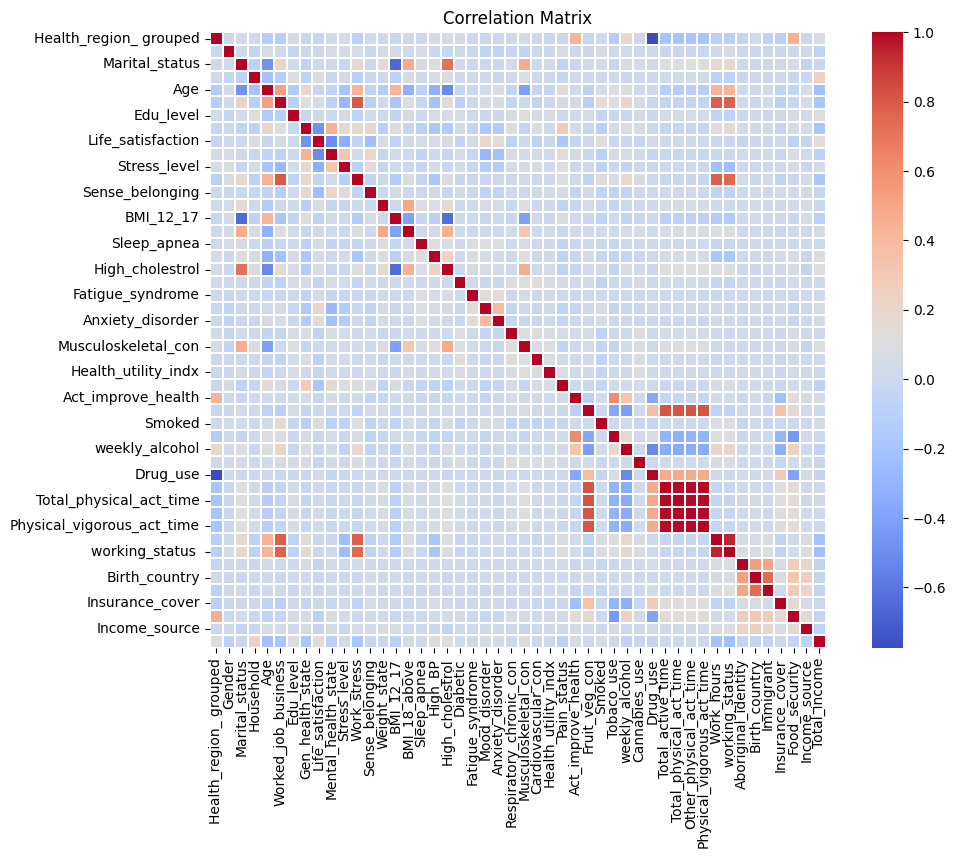

In [93]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', square=True, linewidths=0.1)
plt.title('Correlation Matrix')
plt.show()

## Total_active_time, Total_physical_act_time, Other_physical_act_time and Physical_vigorous_act_time

In [94]:
time_cols = [
    'Total_active_time', 
    'Total_physical_act_time', 
    'Other_physical_act_time', 
    'Physical_vigorous_act_time'
]

grouped_data = df.groupby(time_cols).mean().reset_index()

grouped_data

,Total_active_time,Total_physical_act_time,Other_physical_act_time,Physical_vigorous_act_time,Health_region_ grouped,Gender,Marital_status,Household,Age,Worked_job_business,...,Drug_use,Work_hours,working_status,Aboriginal_identity,Birth_country,Immigrant,Insurance_cover,Food_security,Income_source,Total_income
0,0,0,0,0,39822.118588,1.611469,1.505754,1.614394,4.504193,4.720499,...,2.957285,85.352838,5.108641,2.167349,1.324751,2.007022,4.583187,0.388531,2.389507,3.558611
1,0,0,10,0,39551.440000,1.640000,1.480000,1.600000,4.320000,4.800000,...,2.960000,83.920000,5.040000,2.280000,1.040000,1.960000,3.760000,0.280000,1.920000,3.680000
2,0,0,10,10,37911.285714,1.571429,1.428571,1.714286,4.714286,4.571429,...,3.142857,88.000000,5.285714,2.000000,1.142857,1.857143,3.857143,0.285714,1.571429,3.857143
3,0,0,11,71,48932.000000,1.000000,1.000000,2.000000,5.000000,6.000000,...,2.000000,96.000000,6.000000,2.000000,2.000000,1.000000,6.000000,0.000000,2.000000,5.000000
4,0,0,12,0,48935.000000,2.000000,1.000000,2.000000,5.000000,6.000000,...,2.000000,96.000000,6.000000,1.000000,1.000000,2.000000,6.000000,0.000000,2.000000,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6209,9999,360,1500,120,48934.000000,1.000000,1.000000,2.000000,3.000000,1.000000,...,2.000000,50.000000,1.000000,2.000000,1.000000,2.000000,6.000000,0.000000,9.000000,5.000000
6210,9999,420,0,420,48932.000000,2.000000,1.000000,2.000000,3.000000,1.000000,...,2.000000,50.000000,1.000000,2.000000,1.000000,2.000000,6.000000,0.000000,1.000000,5.000000
6211,9999,9999,9999,9999,39161.375000,1.750000,1.750000,1.375000,4.750000,4.750000,...,5.625000,89.375000,5.750000,5.500000,5.125000,5.375000,6.125000,5.625000,4.250000,3.500000
6212,10080,0,0,0,11900.000000,2.000000,1.000000,2.000000,3.000000,1.000000,...,6.000000,30.000000,1.000000,2.000000,1.000000,2.000000,6.000000,0.000000,1.000000,5.000000


In [95]:
# sns.pairplot(df, vars=time_cols, 
#                 hue='Life_satisfaction',
#              kind='scatter', diag_kind='kde')
# plt.suptitle('Pairplot of Physical Activity Variables', y=1.02)
# plt.show()

(104052, 4)
       Total_active_time  Total_physical_act_time  Other_physical_act_time  \
count      104052.000000            104052.000000            104052.000000   
mean         8112.376158              8106.157950              8125.743148   
std          3887.524446              3892.976293              3867.094852   
min             0.000000                 0.000000                 0.000000   
25%          9996.000000              9996.000000              9996.000000   
50%          9996.000000              9996.000000              9996.000000   
75%          9996.000000              9996.000000              9996.000000   
max         10080.000000             10080.000000              9999.000000   

       Physical_vigorous_act_time  
count               104052.000000  
mean                  8118.224253  
std                   3897.321413  
min                      0.000000  
25%                   9996.000000  
50%                   9996.000000  
75%                   9996.000000

<Axes: >

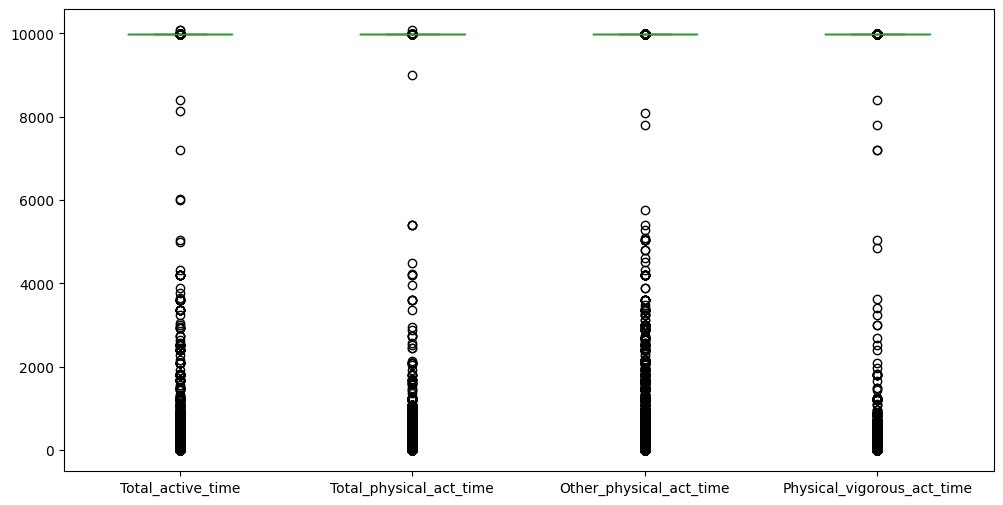

In [96]:
print(df[time_cols].shape)
print(df[time_cols].describe())
print(df[time_cols].value_counts().head(10))
df[time_cols].plot(kind='box', figsize=(12, 6))

看來 time_cols 這四個特徵有很多 0 跟 9996, 9997, 9998, 9999。\
在 doc 中寫 99996, 99997, 99998, 99999 是 invalid，但看來四位數的才是invalid

drop_invalid_times.shape: (104052, 48)
       Total_active_time  Total_physical_act_time  Other_physical_act_time  \
count       19466.000000             19466.000000             19466.000000   
mean           99.111425                92.312083               147.460084   
std           316.459555               231.824416               422.710285   
min             0.000000                 0.000000                 0.000000   
25%             0.000000                 0.000000                 0.000000   
50%             0.000000                 0.000000                 0.000000   
75%            90.000000               120.000000               120.000000   
max         10080.000000             10080.000000              8101.000000   

       Physical_vigorous_act_time  
count                19466.000000  
mean                    32.344652  
std                    170.331638  
min                      0.000000  
25%                      0.000000  
50%                      0.000000  
75%   

<Axes: >

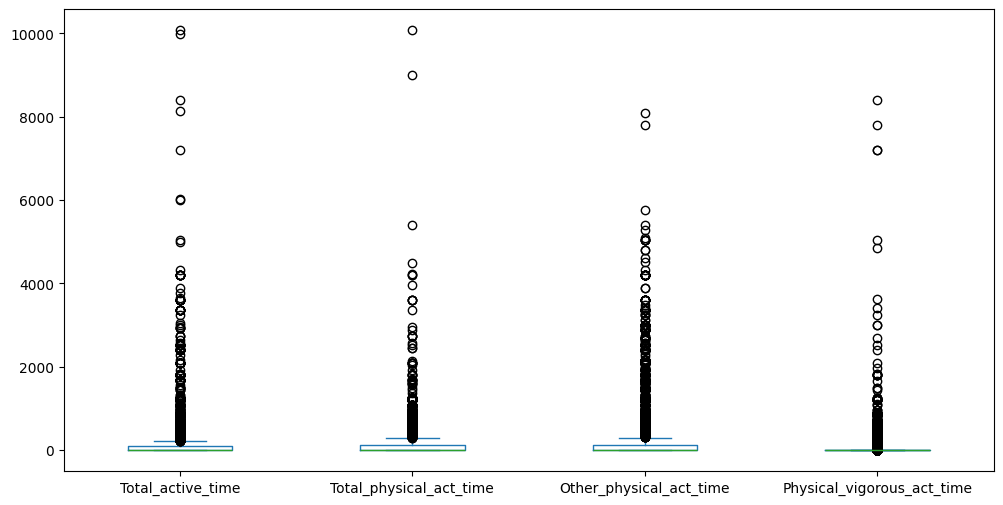

In [101]:
drop_invalid_times = df.copy()
drop_invalid_times[time_cols] = df[time_cols].replace([9996, 9997, 9998, 9999], np.nan) \
      .dropna(subset=time_cols)
print(f'drop_invalid_times.shape: {drop_invalid_times.shape}')         
print(drop_invalid_times[time_cols].describe())
print(drop_invalid_times[time_cols].value_counts().head(10))
drop_invalid_times[time_cols].plot(kind='box', figsize=(12, 6))

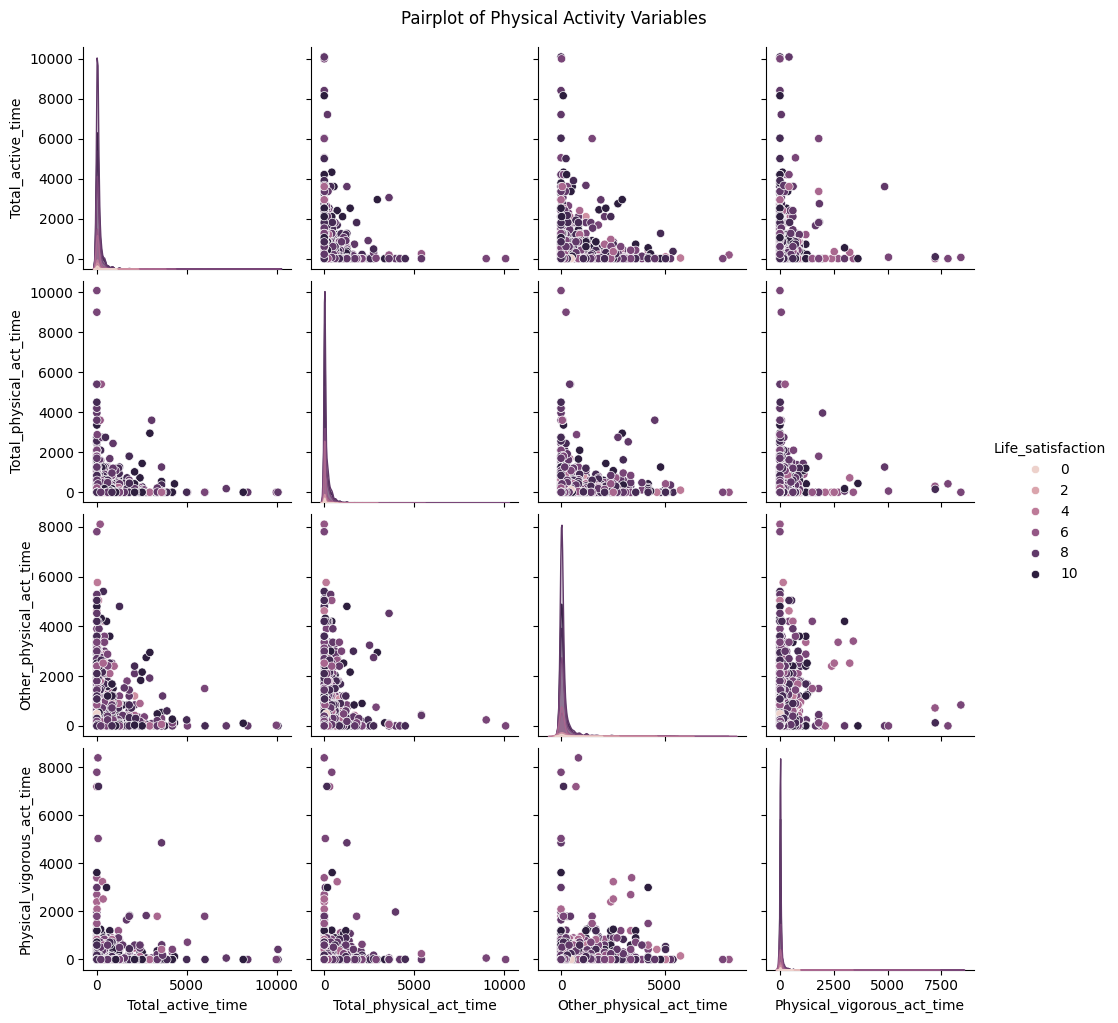

In [98]:
sns.pairplot(drop_invalid_times, vars=time_cols, 
             hue='Life_satisfaction',
             kind='scatter', diag_kind='kde')
plt.suptitle('Pairplot of Physical Activity Variables', y=1.02)
plt.show()

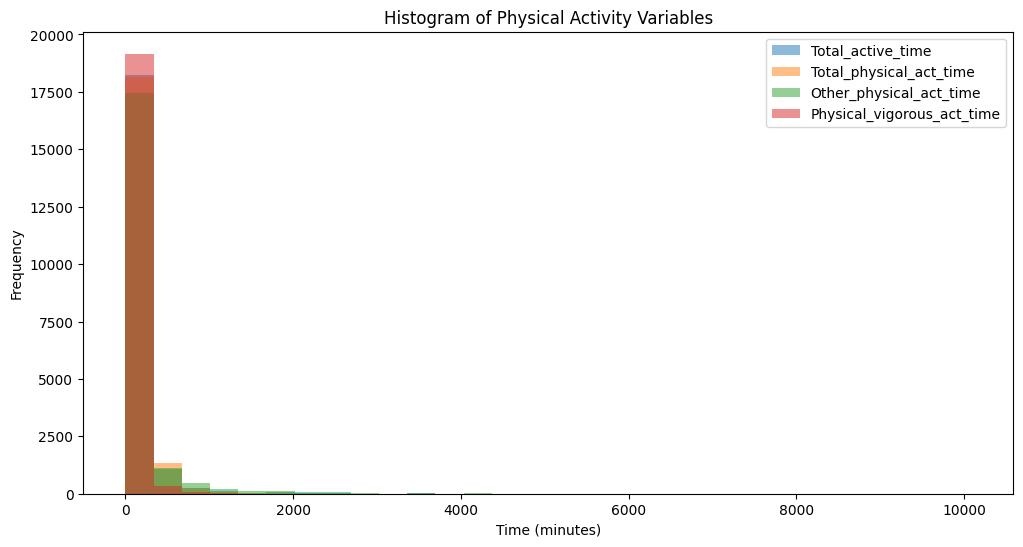

In [99]:
# time_cols 的疊圖
drop_invalid_times[time_cols].plot(kind='hist', 
                                     bins=30, 
                                     alpha=0.5, 
                                     figsize=(12, 6))
plt.title('Histogram of Physical Activity Variables')
plt.xlabel('Time (minutes)')
plt.ylabel('Frequency')
plt.legend(time_cols)
plt.show()

In [100]:
corrs = df[['Total_active_time',
            'Total_physical_act_time', 
            'Other_physical_act_time', 
            'Physical_vigorous_act_time', 
            'Life_satisfaction']].corr()
print("Correlation coefficients between physical activity variables and life satisfaction:")
corrs

Correlation coefficients between physical activity variables and life satisfaction:


,Total_active_time,Total_physical_act_time,Other_physical_act_time,Physical_vigorous_act_time,Life_satisfaction
Total_active_time,1.000000,0.992961,0.989642,0.989807,0.011582
Total_physical_act_time,0.992961,1.000000,0.991873,0.990097,0.010876
Other_physical_act_time,0.989642,0.991873,1.000000,0.989670,0.009944
Physical_vigorous_act_time,0.989807,0.990097,0.989670,1.000000,0.009210
Life_satisfaction,0.011582,0.010876,0.009944,0.009210,1.000000


結論：\
可以把 time_cols 合併，並且 invalid 應該是四位數的 9，不是五位數。\
考慮用 qcut 做分類。